# Reporte 02: Nivel de Cobertura Espacial Capilar (C)

## 1. Justificación Teórica
El presente indicador evalúa la equidad espacial de la red de transporte masivo. Se define un isócrono de accesibilidad peatonal (radio de caminata o *Buffer*) alrededor de cada estación, típicamente de **800 metros** (equivalente a 10-15 minutos caminando).  
**Definir área metropolitana en un polígono de CDXM y algunos municipios de EDOMEX**  


El Nivel de Cobertura ($C$) se calcula intersectando el área de influencia de las estaciones ($A_{cubierta}$) contra la superficie geodésica total de la demarcación política ($A_{total}$):

$$C = \left( \frac{A_{cubierta}}{A_{total}} \right) \times 100$$  

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import warnings
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Silenciar advertencias futuras para un reporte limpio
warnings.filterwarnings('ignore', category=FutureWarning)

proyecto_path = os.path.abspath('..')
if proyecto_path not in sys.path:
    sys.path.append(proyecto_path)

from src.infrastructure.go_client.client import fetch_full_network
from src.infrastructure.go_client.client_spatial import fetch_territorial_polygons
from src.core.algorithms.topologicalIndicators.spatial_coverate import SpatialCoverageAnalyzer

print("Extrayendo datos espaciales y de red desde Go...")
transporte_data = await fetch_full_network()
poligonos_data = await fetch_territorial_polygons(entidades=["Ciudad de México", "México"])

analizador_cobertura = SpatialCoverageAnalyzer(transporte_data, poligonos_data)
print("✅ Datos cargados y proyectados a métrica local (EPSG:32614).")

# Lista estricta para segmentación espacial
ALCALDIAS_CDMX = [
    'Álvaro Obregón', 'Azcapotzalco', 'Benito Juárez', 'Coyoacán', 
    'Cuajimalpa de Morelos', 'Cuauhtémoc', 'Gustavo A. Madero', 'Iztacalco', 
    'Iztapalapa', 'La Magdalena Contreras', 'Miguel Hidalgo', 'Milpa Alta', 
    'Tláhuac', 'Tlalpan', 'Venustiano Carranza', 'Xochimilco'
]

Extrayendo datos espaciales y de red desde Go...
2026-04-18 22:24:32 | INFO     | VFT_Model | Construyendo el puente hacia el módulo espacial de Go...
2026-04-18 22:24:32 | INFO     | VFT_Model | Solicitando capa espacial a: http://localhost:8080/movilidad/mapas/geojsonEstacion
2026-04-18 22:24:32 | INFO     | VFT_Model | Solicitando capa espacial a: http://localhost:8080/movilidad/mapas/geojsonLinea
2026-04-18 22:24:32 | INFO     | VFT_Model | Red extraída: 22766 entidades espaciales listas para VFT.
2026-04-18 22:24:32 | INFO     | VFT_Model | Solicitando polígonos territoriales a APIMETRO para: ['Ciudad de México', 'México']
2026-04-18 22:24:32 | INFO     | VFT_Model | Polígonos combinados exitosamente. Total features: 157
✅ Datos cargados y proyectados a métrica local (EPSG:32614).


In [2]:
RADIO_METROS = 800.0

print(f"Calculando cobertura general agregada (Isócrono: {RADIO_METROS}m)...")
df_general = analizador_cobertura.calculate_general_coverage(radio_caminable_m=RADIO_METROS)

print("Calculando coberturas independientes por sistema...")
dict_sistemas = analizador_cobertura.calculate_coverage_by_system(radio_caminable_m=RADIO_METROS)

print("✅ Cálculos finalizados.")

Calculando cobertura general agregada (Isócrono: 800.0m)...
Calculando coberturas independientes por sistema...
✅ Cálculos finalizados.


## 1. Escenario Base: Cobertura Total del Sistema de Transporte

Análisis de las demarcaciones con **mayor rezago** (menor porcentaje de cobertura espacial), evidenciando las zonas de exclusión al transporte masivo.

### 🔻 Peores 5 Coberturas - Alcaldías (CDMX)

,Demarcacion,Area_Total_km2,Area_Cubierta_km2,Cobertura_Porcentaje
68,Milpa Alta,298.01,35.00,11.75
59,La Magdalena Contreras,63.37,16.33,25.76
117,Tlalpan,314.25,94.31,30.01
119,Tláhuac,85.78,43.85,51.12
33,Cuajimalpa de Morelos,71.10,37.12,52.20


### 🔻 Peores 5 Coberturas - Municipios (EDOMEX)

,Demarcacion,Area_Total_km2,Area_Cubierta_km2,Cobertura_Porcentaje
121,Tonanitla,8.52,0.0,0.0
20,Capulhuac,21.50,0.0,0.0
19,Calimaya,104.26,0.0,0.0
37,Donato Guerra,181.36,0.0,0.0
16,Ayapango,50.83,0.0,0.0


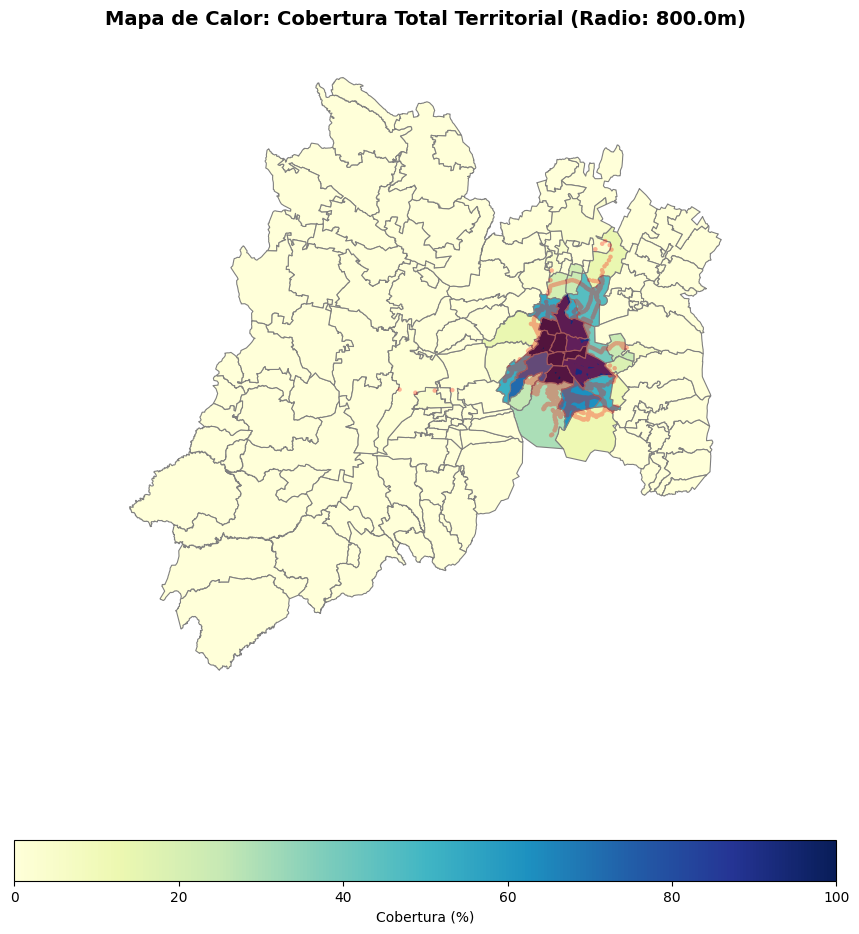

In [3]:
display(Markdown(f"## 1. Escenario Base: Cobertura Total del Sistema de Transporte"))
display(Markdown("Análisis de las demarcaciones con **mayor rezago** (menor porcentaje de cobertura espacial), evidenciando las zonas de exclusión al transporte masivo."))

# Separar CDMX y EDOMEX
df_general_cdmx = df_general[df_general['Demarcacion'].isin(ALCALDIAS_CDMX)]
df_general_edomex = df_general[~df_general['Demarcacion'].isin(ALCALDIAS_CDMX)]

# Extraer los peores 5 (Bottom 5)
peores_cdmx = df_general_cdmx.sort_values('Cobertura_Porcentaje', ascending=True).head(5)
peores_edomex = df_general_edomex.sort_values('Cobertura_Porcentaje', ascending=True).head(5)

# Mostrar Tablas
display(Markdown(f"### 🔻 Peores 5 Coberturas - Alcaldías (CDMX)"))
display(peores_cdmx[['Demarcacion', 'Area_Total_km2', 'Area_Cubierta_km2', 'Cobertura_Porcentaje']])

display(Markdown(f"### 🔻 Peores 5 Coberturas - Municipios (EDOMEX)"))
display(peores_edomex[['Demarcacion', 'Area_Total_km2', 'Area_Cubierta_km2', 'Cobertura_Porcentaje']])

# Preparar y mostrar el Mapa General
gdf_mapa_general = analizador_cobertura.gdf_poligonos.copy()
gdf_mapa_general = gdf_mapa_general.merge(df_general, left_on='nombre', right_on='Demarcacion', how='left')

fig, ax = plt.subplots(1, 1, figsize=(14, 10))
ax.set_title(f"Mapa de Calor: Cobertura Total Territorial (Radio: {RADIO_METROS}m)", fontsize=14, fontweight='bold')

gdf_mapa_general.plot(
    column='Cobertura_Porcentaje', cmap='YlGnBu', linewidth=0.8, ax=ax, edgecolor='0.5',
    legend=True, legend_kwds={'label': "Cobertura (%)", 'orientation': "horizontal", 'shrink': 0.6},
    missing_kwds={"color": "lightgrey", "label": "Sin Datos"}
)

# Plotear la mancha unida
buffers_gen = analizador_cobertura.gdf_estaciones.geometry.buffer(RADIO_METROS)
mancha_gen = gpd.GeoSeries([buffers_gen.unary_union])
mancha_gen.plot(ax=ax, color='red', alpha=0.3, linewidth=0)

ax.set_axis_off()
plt.tight_layout()
plt.show()

## 2. Desglose Operativo por Sistema

A continuación se evalúa el nivel de penetración territorial de cada sistema de manera aislada, destacando las demarcaciones centrales de la Ciudad de México con mayor nivel de servicio.

---

### 🚇 Sistema: CC

**Top 5 Alcaldías (CDMX) con mayor cobertura**

,Demarcacion,Area_Total_km2,Area_Cubierta_km2,Cobertura_Porcentaje
34,Cuauhtémoc,32.50,32.47,99.90
18,Benito Juárez,26.68,26.32,98.65
50,Iztacalco,23.08,22.25,96.42
67,Miguel Hidalgo,46.39,44.33,95.57
127,Venustiano Carranza,33.84,27.77,82.06


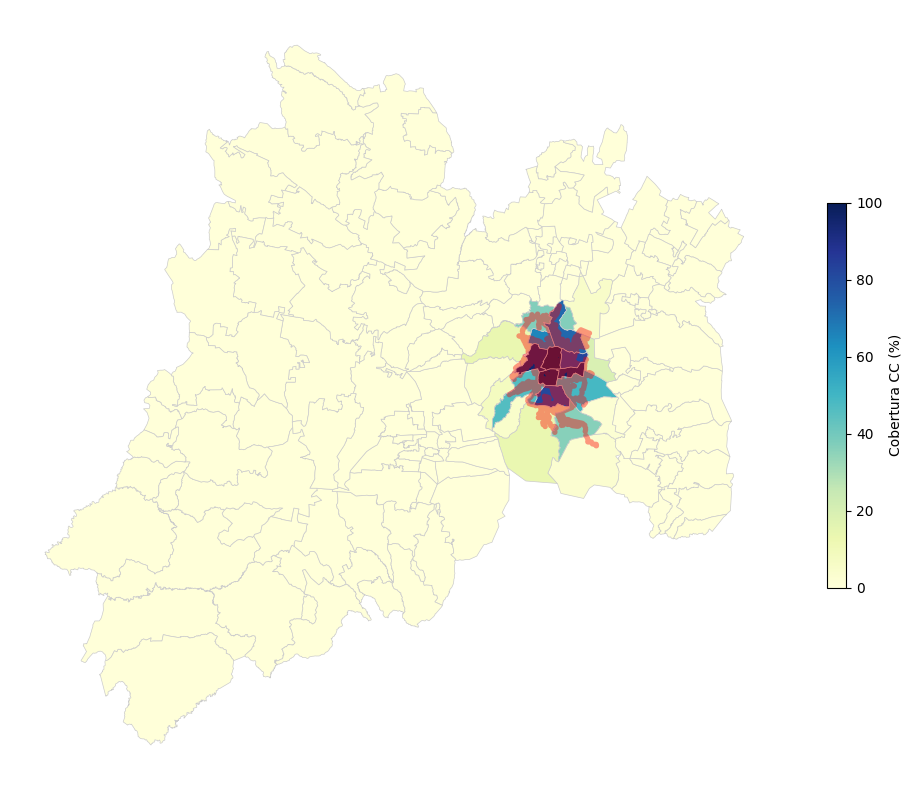

---

### 🚇 Sistema: RTP

**Top 5 Alcaldías (CDMX) con mayor cobertura**

,Demarcacion,Area_Total_km2,Area_Cubierta_km2,Cobertura_Porcentaje
67,Miguel Hidalgo,46.39,41.90,90.32
34,Cuauhtémoc,32.50,29.32,90.22
17,Azcapotzalco,33.50,30.08,89.81
41,Gustavo A. Madero,87.84,75.86,86.37
51,Iztapalapa,113.07,93.66,82.83


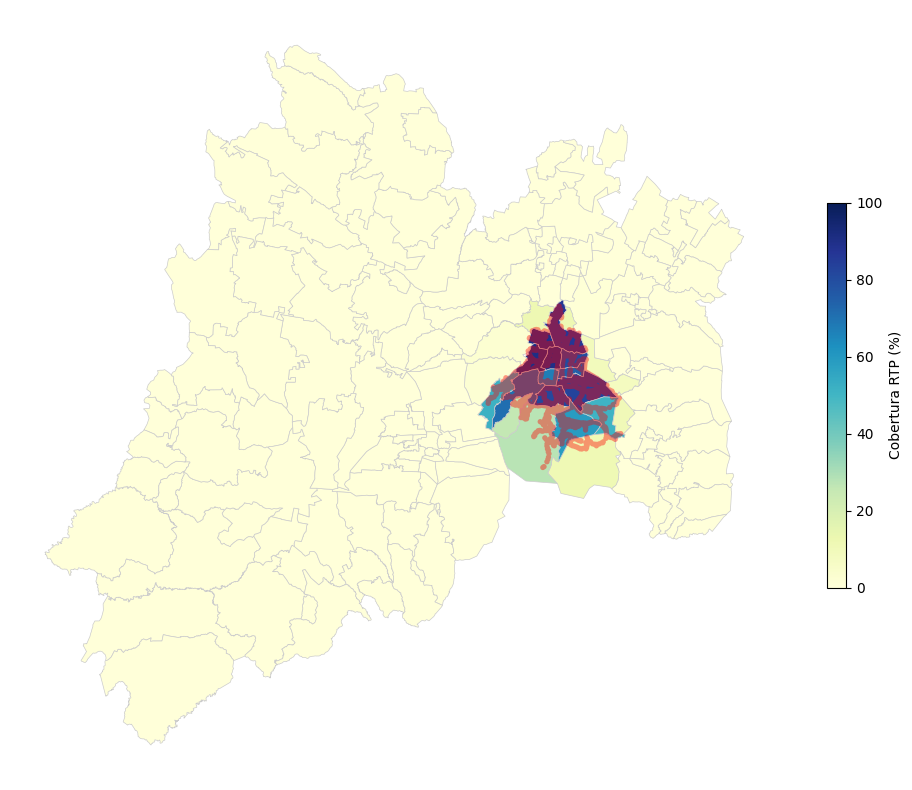

---

### 🚇 Sistema: TROLE

**Top 5 Alcaldías (CDMX) con mayor cobertura**

,Demarcacion,Area_Total_km2,Area_Cubierta_km2,Cobertura_Porcentaje
34,Cuauhtémoc,32.50,22.72,69.90
18,Benito Juárez,26.68,16.50,61.85
17,Azcapotzalco,33.50,17.48,52.18
50,Iztacalco,23.08,11.93,51.69
31,Coyoacán,53.88,25.17,46.71


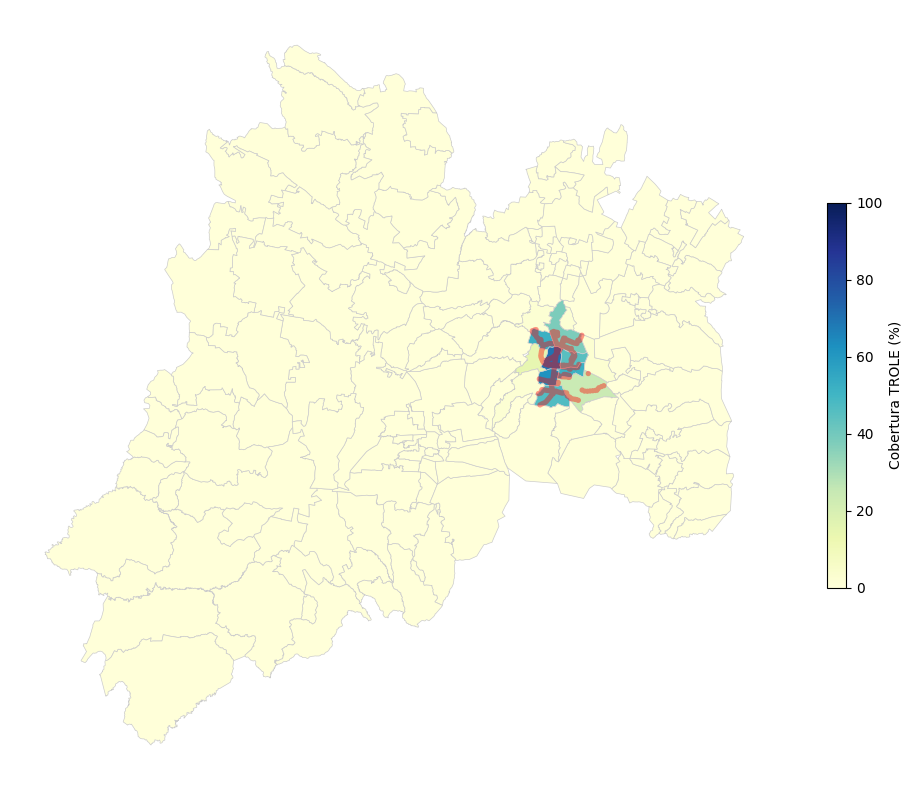

---

### 🚇 Sistema: MEXIBÚS

**Top 5 Alcaldías (CDMX) con mayor cobertura**

,Demarcacion,Area_Total_km2,Area_Cubierta_km2,Cobertura_Porcentaje
50,Iztacalco,23.08,1.52,6.58
127,Venustiano Carranza,33.84,1.90,5.62
41,Gustavo A. Madero,87.84,3.23,3.67
133,Xochimilco,114.03,0.00,0.00
119,Tláhuac,85.78,0.00,0.00


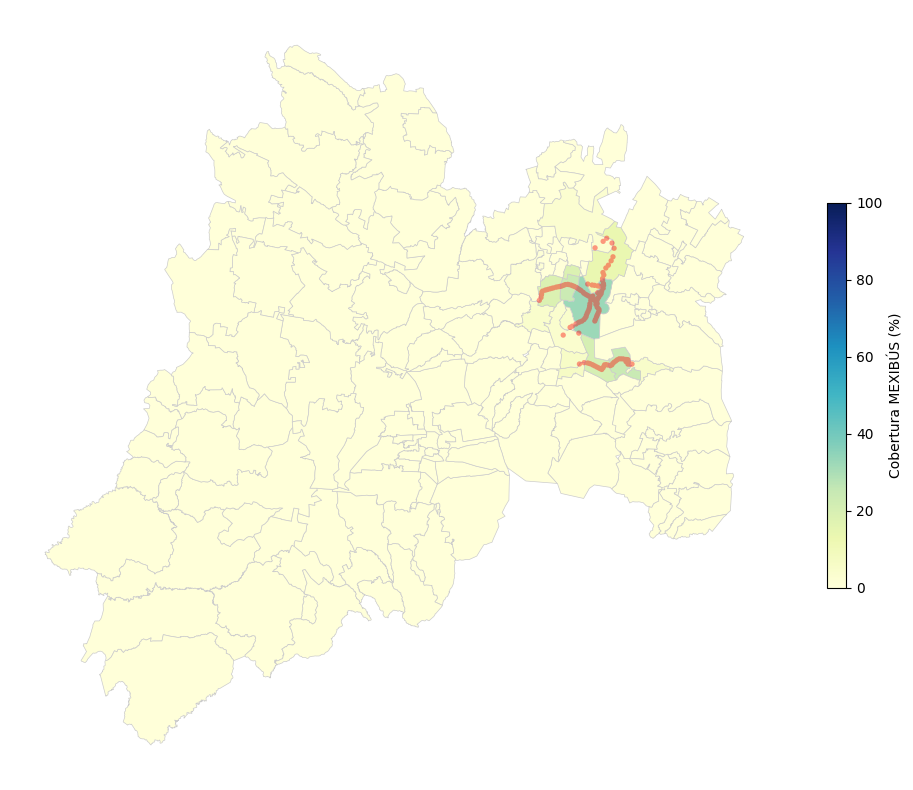

---

### 🚇 Sistema: MB

**Top 5 Alcaldías (CDMX) con mayor cobertura**

,Demarcacion,Area_Total_km2,Area_Cubierta_km2,Cobertura_Porcentaje
34,Cuauhtémoc,32.50,26.74,82.27
18,Benito Juárez,26.68,16.21,60.74
50,Iztacalco,23.08,13.95,60.44
127,Venustiano Carranza,33.84,16.10,47.58
41,Gustavo A. Madero,87.84,38.75,44.12


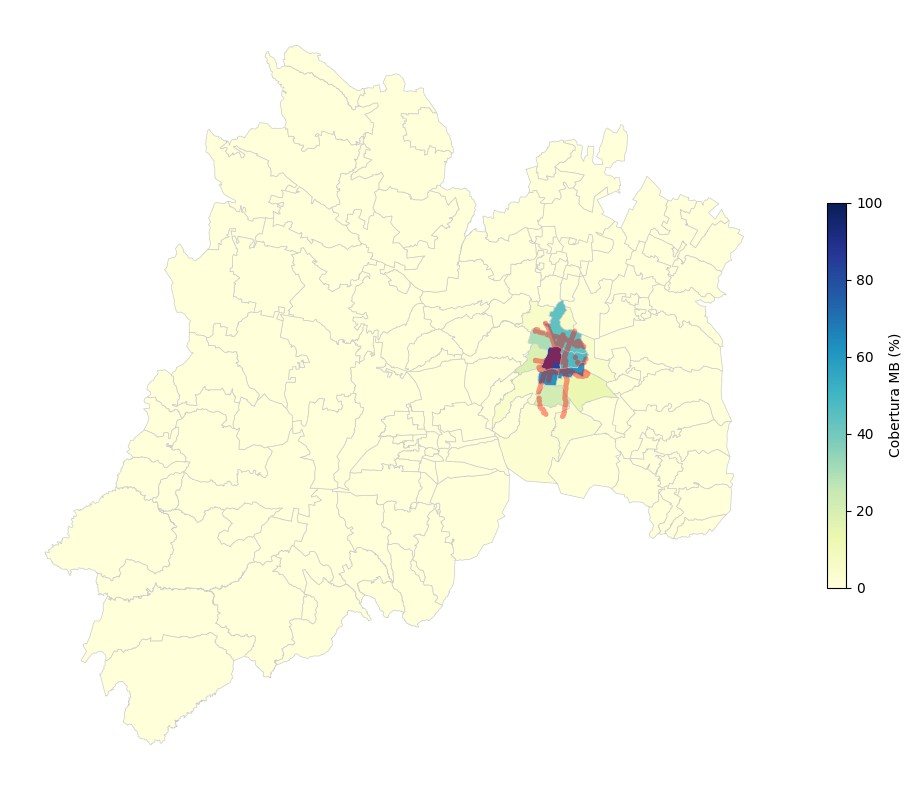

---

### 🚇 Sistema: PUMABUS

**Top 5 Alcaldías (CDMX) con mayor cobertura**

,Demarcacion,Area_Total_km2,Area_Cubierta_km2,Cobertura_Porcentaje
31,Coyoacán,53.88,10.85,20.13
140,Álvaro Obregón,95.82,2.25,2.34
117,Tlalpan,314.25,0.25,0.08
127,Venustiano Carranza,33.84,0.00,0.00
133,Xochimilco,114.03,0.00,0.00


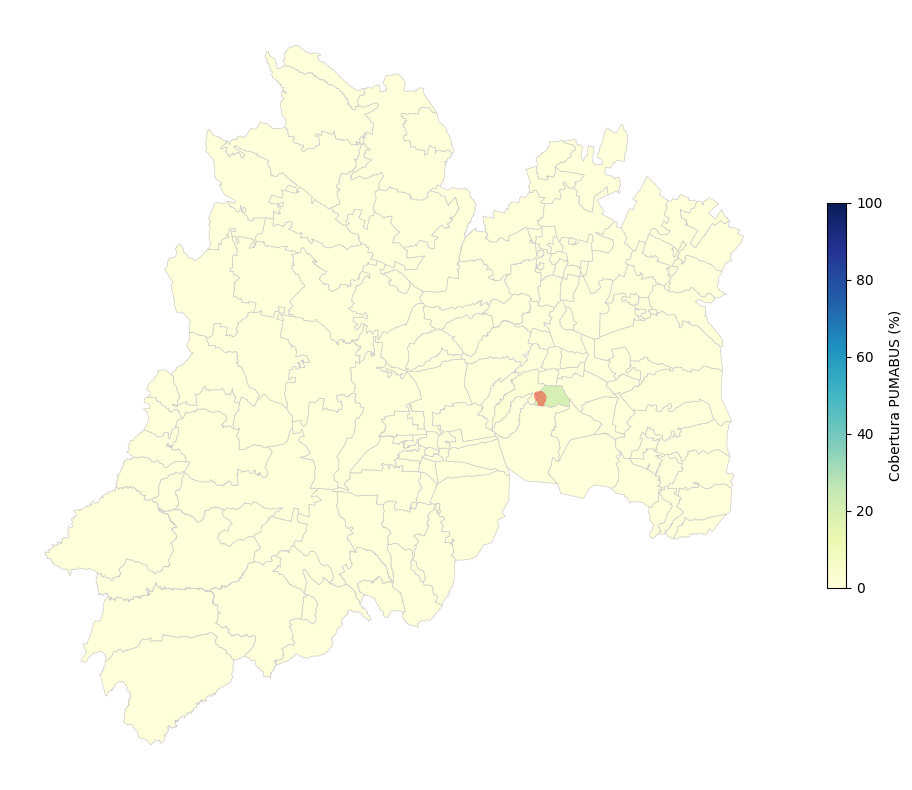

---

### 🚇 Sistema: METRO

**Top 5 Alcaldías (CDMX) con mayor cobertura**

,Demarcacion,Area_Total_km2,Area_Cubierta_km2,Cobertura_Porcentaje
34,Cuauhtémoc,32.50,28.35,87.23
18,Benito Juárez,26.68,21.34,79.99
127,Venustiano Carranza,33.84,24.39,72.07
50,Iztacalco,23.08,11.66,50.52
17,Azcapotzalco,33.50,13.80,41.18


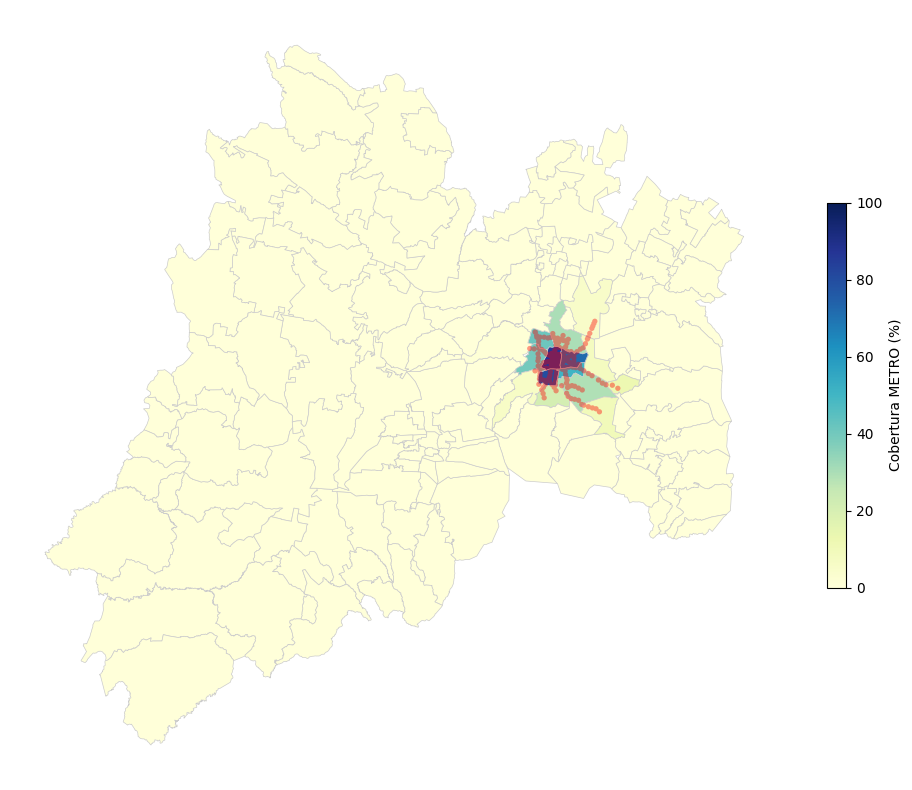

---

### 🚇 Sistema: SUB

**Top 5 Alcaldías (CDMX) con mayor cobertura**

,Demarcacion,Area_Total_km2,Area_Cubierta_km2,Cobertura_Porcentaje
34,Cuauhtémoc,32.50,2.01,6.18
17,Azcapotzalco,33.50,2.01,5.99
133,Xochimilco,114.03,0.00,0.00
127,Venustiano Carranza,33.84,0.00,0.00
119,Tláhuac,85.78,0.00,0.00


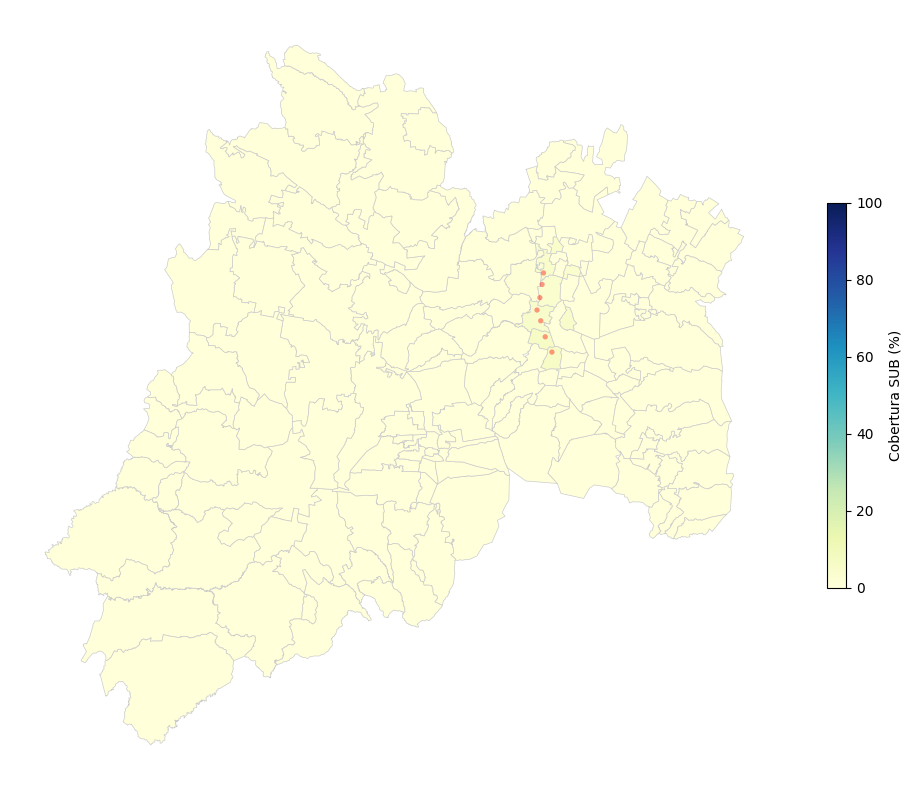

---

### 🚇 Sistema: CBB

**Top 5 Alcaldías (CDMX) con mayor cobertura**

,Demarcacion,Area_Total_km2,Area_Cubierta_km2,Cobertura_Porcentaje
41,Gustavo A. Madero,87.84,11.31,12.88
67,Miguel Hidalgo,46.39,5.50,11.85
51,Iztapalapa,113.07,12.74,11.27
140,Álvaro Obregón,95.82,4.38,4.57
127,Venustiano Carranza,33.84,0.00,0.00


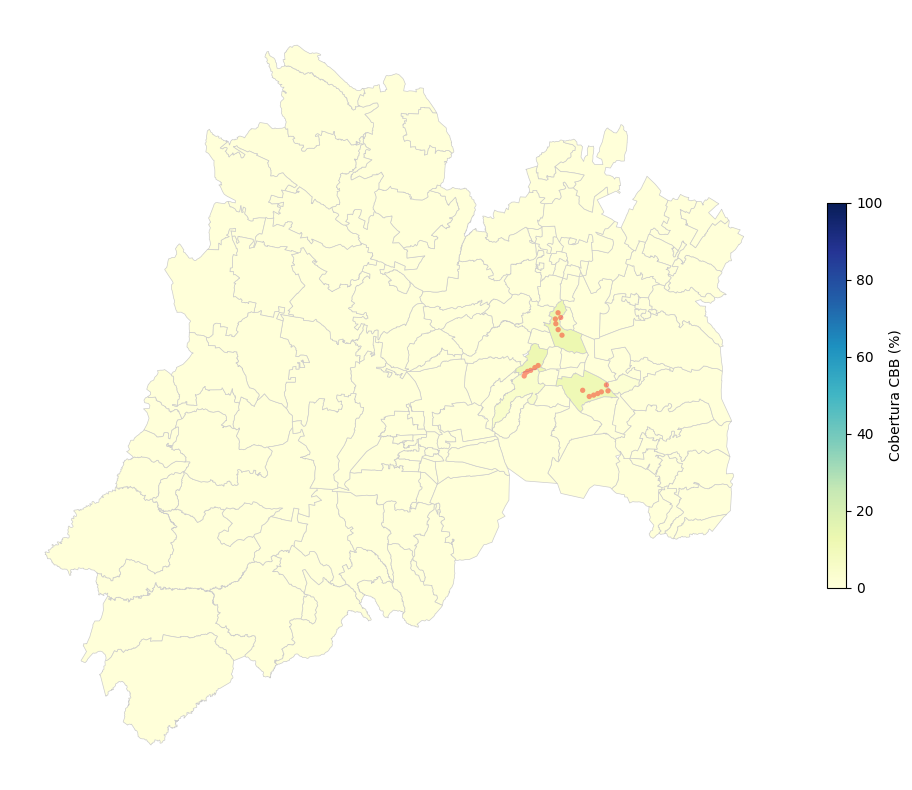

---

### 🚇 Sistema: MEXICABLE

**Top 5 Alcaldías (CDMX) con mayor cobertura**

,Demarcacion,Area_Total_km2,Area_Cubierta_km2,Cobertura_Porcentaje
41,Gustavo A. Madero,87.84,2.8,3.19
127,Venustiano Carranza,33.84,0.0,0.00
133,Xochimilco,114.03,0.0,0.00
119,Tláhuac,85.78,0.0,0.00
117,Tlalpan,314.25,0.0,0.00


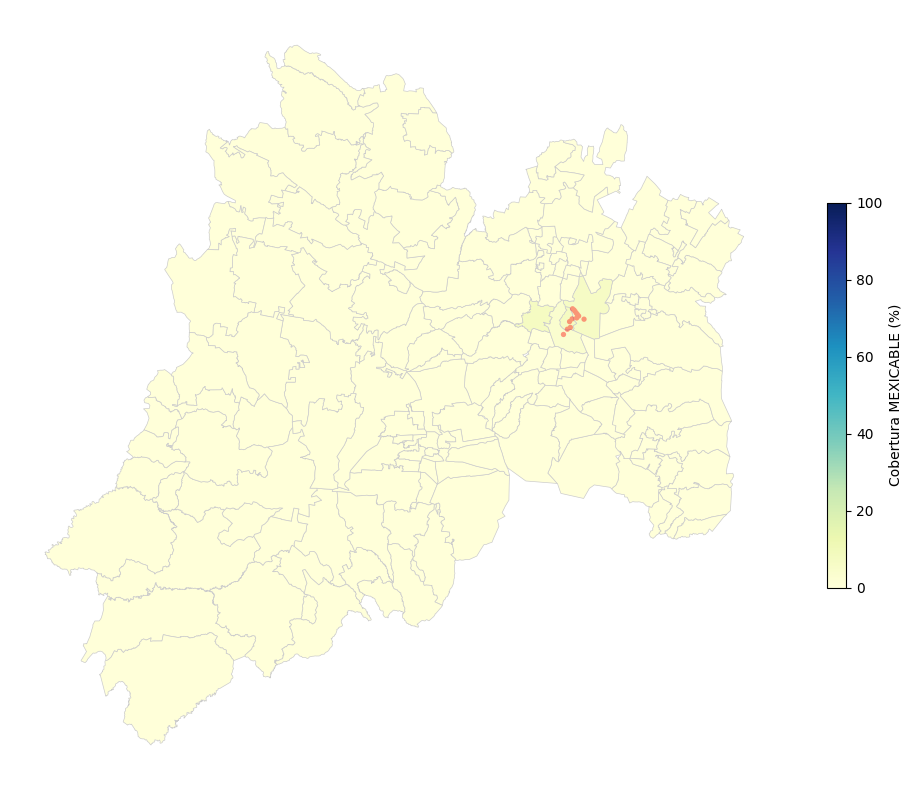

---

### 🚇 Sistema: TL

**Top 5 Alcaldías (CDMX) con mayor cobertura**

,Demarcacion,Area_Total_km2,Area_Cubierta_km2,Cobertura_Porcentaje
31,Coyoacán,53.88,9.31,17.28
133,Xochimilco,114.03,6.82,5.98
117,Tlalpan,314.25,4.07,1.30
127,Venustiano Carranza,33.84,0.00,0.00
119,Tláhuac,85.78,0.00,0.00


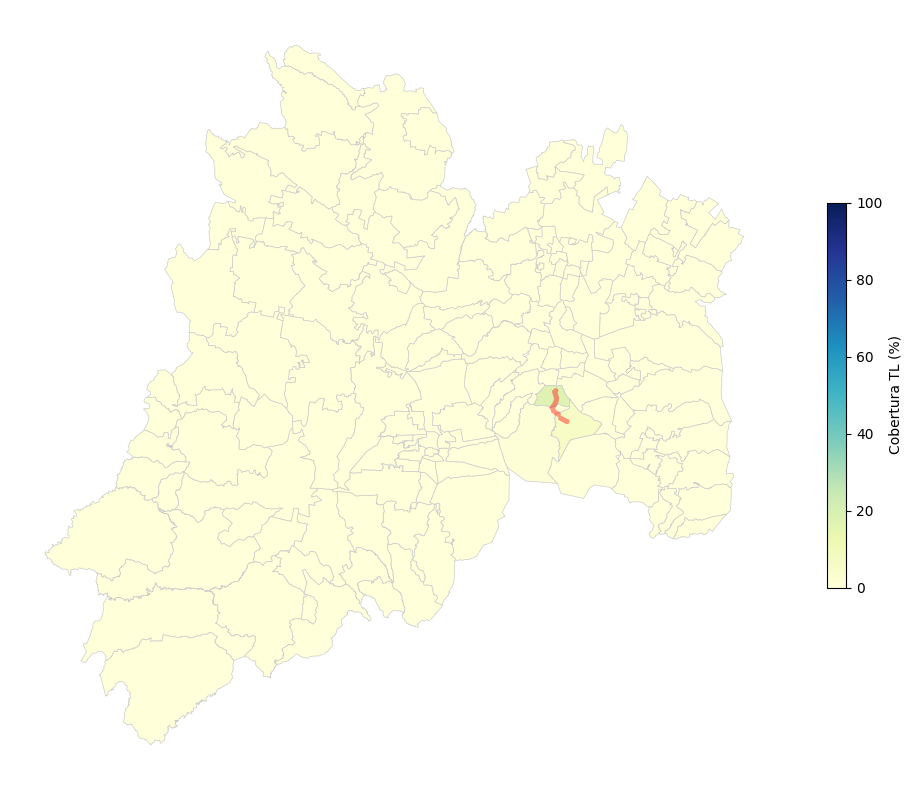

---

### 🚇 Sistema: INTERURBANO

**Top 5 Alcaldías (CDMX) con mayor cobertura**

,Demarcacion,Area_Total_km2,Area_Cubierta_km2,Cobertura_Porcentaje
33,Cuajimalpa de Morelos,71.10,1.59,2.23
140,Álvaro Obregón,95.82,0.42,0.44
127,Venustiano Carranza,33.84,0.00,0.00
133,Xochimilco,114.03,0.00,0.00
119,Tláhuac,85.78,0.00,0.00


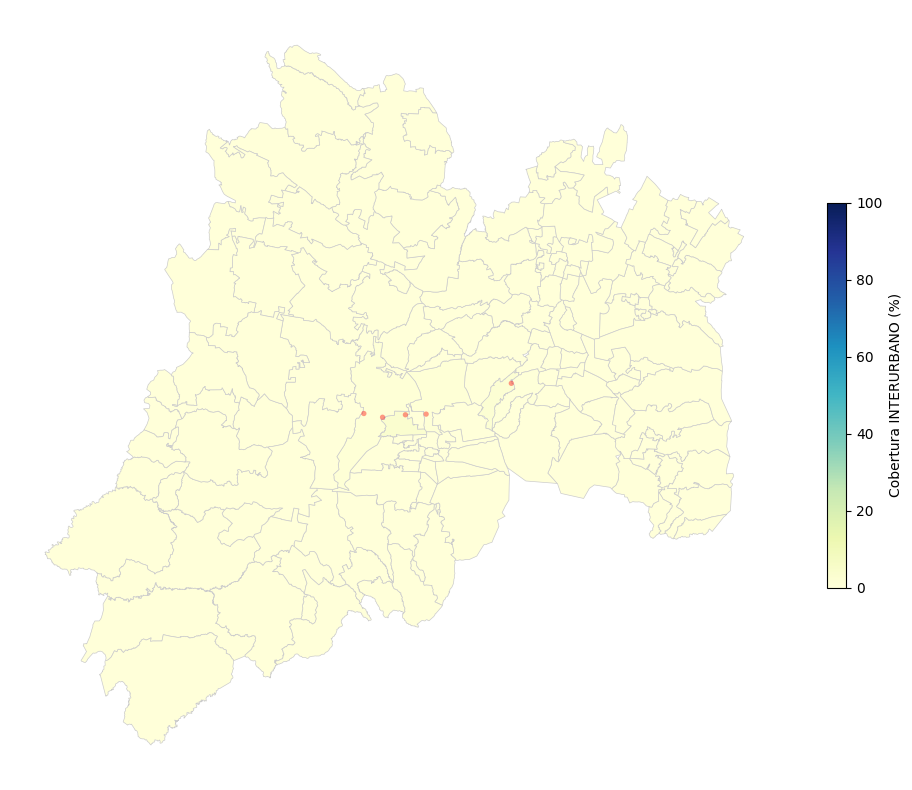

In [4]:
display(Markdown(f"## 2. Desglose Operativo por Sistema"))
display(Markdown("A continuación se evalúa el nivel de penetración territorial de cada sistema de manera aislada, destacando las demarcaciones centrales de la Ciudad de México con mayor nivel de servicio."))

# Filtrar sistemas válidos
sistemas_plot = [sis for sis in dict_sistemas.keys() if not dict_sistemas[sis].empty]

for sistema in sistemas_plot:
    df_sis = dict_sistemas[sistema]
    
    # Filtrar SOLO CDMX para el Top 5
    df_sis_cdmx = df_sis[df_sis['Demarcacion'].isin(ALCALDIAS_CDMX)]
    top5_cdmx = df_sis_cdmx.sort_values('Cobertura_Porcentaje', ascending=False).head(5)
    
    # 1. Imprimir Títulos y Tabla
    display(Markdown(f"---"))
    display(Markdown(f"### 🚇 Sistema: {str(sistema).upper()}"))
    display(Markdown(f"**Top 5 Alcaldías (CDMX) con mayor cobertura**"))
    display(top5_cdmx[['Demarcacion', 'Area_Total_km2', 'Area_Cubierta_km2', 'Cobertura_Porcentaje']])
    
    # 2. Dibujar su mapa
    gdf_sis = analizador_cobertura.gdf_poligonos.copy()
    gdf_sis = gdf_sis.merge(df_sis, left_on='nombre', right_on='Demarcacion', how='left')
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    # Mapa coroplético (escala fija 0-100 para comparar peras con peras)
    gdf_sis.plot(
        column='Cobertura_Porcentaje', cmap='YlGnBu', linewidth=0.5, ax=ax, edgecolor='0.8',
        legend=True, vmin=0, vmax=100, 
        legend_kwds={'shrink': 0.5, 'label': f'Cobertura {str(sistema).upper()} (%)'}, 
        missing_kwds={"color": "lightgrey"}
    )
    
    # Agregar las estaciones de ese sistema en específico
    estaciones_sis = analizador_cobertura.gdf_estaciones[analizador_cobertura.gdf_estaciones['sistema'] == sistema]
    if not estaciones_sis.empty:
        buffers_sis = estaciones_sis.geometry.buffer(RADIO_METROS)
        mancha_sis = gpd.GeoSeries([buffers_sis.unary_union])
        mancha_sis.plot(ax=ax, color='red', alpha=0.4, linewidth=0)
        
    ax.set_axis_off()
    plt.tight_layout()
    plt.show() # Forzar a que imprima el mapa antes de pasar al siguiente sistema en el bucle